In [72]:
import pandas as pd
import os
os.chdir("C:/Users/David/OneDrive/Desktop/Archivos EBAC")
df = pd.read_csv("TempNY.csv")
df

,Year,Average,Unnamed: 2
0,1870,53.60,NaN
1,1871,51.13,NaN
2,1872,50.98,NaN
3,1873,50.98,NaN
4,1874,51.34,NaN
...,...,...,...
146,2016,57.18,NaN
147,2017,56.22,NaN
148,2018,55.88,NaN
149,2019,55.62,NaN


In [76]:
df = df.drop("Unnamed: 2", axis = 1)
df

,Year,Average
0,1870,53.60
1,1871,51.13
2,1872,50.98
3,1873,50.98
4,1874,51.34
...,...,...
146,2016,57.18
147,2017,56.22
148,2018,55.88
149,2019,55.62


In [77]:
# Cambio de índice princial

df.index = df["Year"]
df = df.drop(["Year"], axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


<Axes: xlabel='Year'>

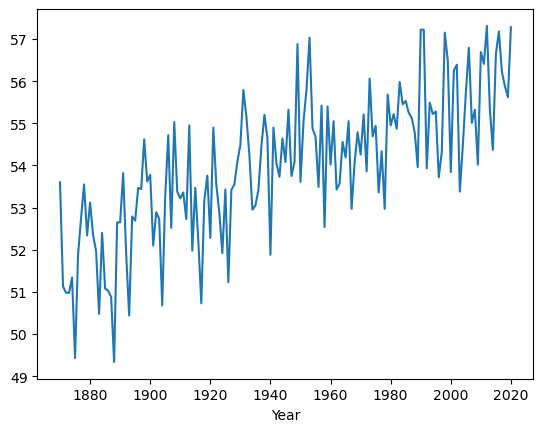

In [78]:
df["Average"].plot()

In [79]:
# Realizar la prueba Dickey-Fuller

# H0: La serie NO ES ESTACIONARIA
# Ha: La serie SÍ ES ESTACIONARIA

from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Average"])
print("El valor p de la prueba de Dickey-Fuller es: ", result[1])

El valor p de la prueba de Dickey-Fuller es:  0.8417172538965355


## Conclusión: No hay evidencia estadística para rechazar H0 (y por lo tanto decir que la serie es estacionaria).

In [80]:
# Aplicar las primeras diferencias

df["temp_change"] = df["Average"].diff()
df

,Average,temp_change
Year,,
1870,53.60,NaN
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
...,...,...
2016,57.18,0.53
2017,56.22,-0.96
2018,55.88,-0.34


In [81]:
df = df.dropna()
df

,Average,temp_change
Year,,
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
1875,49.43,-1.91
...,...,...
2016,57.18,0.53
2017,56.22,-0.96
2018,55.88,-0.34


In [82]:
# Aplicación de la prueba de Dickey-Fuller sobre las diferencias (Como el valor es prácticamente 0 es muy bueno)

result2 = adfuller(df["temp_change"])
print("El valor p de la prueba de Dickey-Fuller es: ", result2[1])

El valor p de la prueba de Dickey-Fuller es:  8.361907414786182e-14


<Axes: xlabel='Year'>

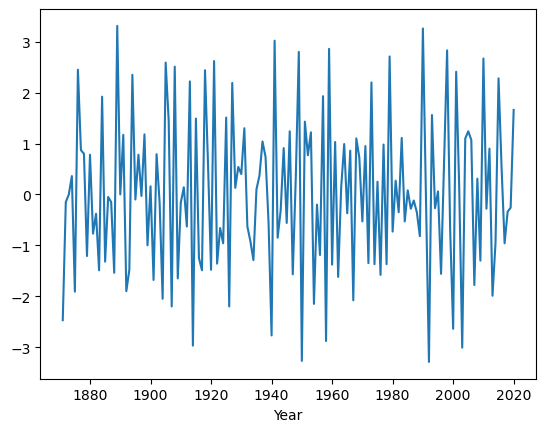

In [83]:
df["temp_change"].plot()

## Conclusión: La serie transformada de diferencias sí es estacionaria.

In [84]:
from statsmodels.tsa.arima.model import ARIMA

In [85]:
# Importación del módulo para estimar un modelo ARIMA

from statsmodels.tsa.arima.model import ARIMA

# Ajustarlos a un modelo AR(1) e imprimir su AIC:

mod_ar1 = ARIMA(df["temp_change"], order = (1,0,0))
res_ar1 = mod_ar1.fit()

print("El índice de Akaike (AIC) para AR(1) es:", res_ar1.aic)

El índice de Akaike (AIC) para AR(1) es: 519.9693852277926


C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [86]:
# Forma general d obtener varios modelos AR(i) e imprimir su AIC:
#for i in range (1,7):
#    mod_ar_i = ARIMA(df["temp_change"], order = (i,0,0))
#    res_ar_i = mod_ar_i.fit()
#    print("El índice de Akaike (AIC) para AR("+ str(i)+") es:", res_ar_i.aic)

In [87]:
df = pd.read_csv("TempNY.csv")
df = df.drop("Unnamed: 2", axis = 1)
df.index = df["Year"]
df = df.drop(["Year"], axis = 1)

In [88]:
# Importación del módulo de ARIMA de statsmodels
from statsmodels.graphics.tsaplots import plot_predict

# Pronóstico de temperaturas usando un modelo ARIMA(0,1,1)

mod = ARIMA(df["Average"], order = (0,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -239.064
Date:                Sat, 08 Aug 2026   AIC                            482.128
Time:                        16:44:25   BIC                            488.149
Sample:                             0   HQIC                           484.574
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8526      0.048    -17.611      0.000      -0.947      -0.758
sigma2         1.4063      0.199      7.057      0.000       1.016       1.797
Ljung-Box (L1) (Q):                   0.21   Jarque-

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [89]:
# Pronóstico de temperaturas usando un modelo ARIMA(0,1,2)

mod = ARIMA(df["Average"], order = (0,1,2))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -238.836
Date:                Sat, 08 Aug 2026   AIC                            483.672
Time:                        16:44:26   BIC                            492.703
Sample:                             0   HQIC                           487.341
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8046      0.090     -8.956      0.000      -0.981      -0.629
ma.L2         -0.0527      0.095     -0.557      0.578      -0.238       0.133
sigma2         1.4022      0.199      7.045      0.0

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [90]:
# Pronóstico de temperaturas usando un modelo ARIMA(1,1,1)

mod = ARIMA(df["Average"], order = (1,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -238.826
Date:                Sat, 08 Aug 2026   AIC                            483.652
Time:                        16:44:26   BIC                            492.683
Sample:                             0   HQIC                           487.321
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0646      0.109      0.590      0.555      -0.150       0.279
ma.L1         -0.8669      0.057    -15.261      0.000      -0.978      -0.756
sigma2         1.4020      0.199      7.043      0.0

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [91]:
# Pronóstico de temperaturas usando un modelo ARIMA(2,1,1)

mod = ARIMA(df["Average"], order = (2,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -238.810
Date:                Sat, 08 Aug 2026   AIC                            485.620
Time:                        16:44:27   BIC                            497.663
Sample:                             0   HQIC                           490.513
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0671      0.110      0.610      0.542      -0.148       0.283
ar.L2          0.0161      0.093      0.173      0.863      -0.166       0.199
ma.L1         -0.8703      0.061    -14.337      0.0

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [92]:
# Pronóstico de temperaturas usando un modelo ARIMA(2,1,2)

mod = ARIMA(df["Average"], order = (2,1,2))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -237.753
Date:                Sat, 08 Aug 2026   AIC                            485.506
Time:                        16:44:28   BIC                            500.559
Sample:                             0   HQIC                           491.621
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8538      0.142     -6.008      0.000      -1.132      -0.575
ar.L2          0.1094      0.107      1.018      0.309      -0.101       0.320
ma.L1          0.0618      0.110      0.564      0.5

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary st

In [93]:
# Pronóstico de temperaturas usando un modelo ARIMA(6,1,1)

mod = ARIMA(df["Average"], order = (6,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(6, 1, 1)   Log Likelihood                -237.040
Date:                Sat, 08 Aug 2026   AIC                            490.081
Time:                        16:44:29   BIC                            514.166
Sample:                             0   HQIC                           499.866
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0540      0.151     -0.359      0.720      -0.349       0.241
ar.L2         -0.0758      0.114     -0.668      0.504      -0.298       0.147
ar.L3         -0.1214      0.110     -1.106      0.2

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


## Conclusión: El pronóstico de temperaturas usando un modelo ARIMA(0,1,1) es el óptimo de los explorados.

In [94]:
# Pronóstico de temperaturas usando un modelo ARIMA(0,1,1)

mod = ARIMA(df["Average"], order = (0,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -239.064
Date:                Sat, 08 Aug 2026   AIC                            482.128
Time:                        16:44:30   BIC                            488.149
Sample:                             0   HQIC                           484.574
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8526      0.048    -17.611      0.000      -0.947      -0.758
sigma2         1.4063      0.199      7.057      0.000       1.016       1.797
Ljung-Box (L1) (Q):                   0.21   Jarque-

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [95]:
# Pronóstico puntual de los próximos 5 años

predicciones = res.forecast(5)
predicciones

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


151    56.10182
152    56.10182
153    56.10182
154    56.10182
155    56.10182
Name: predicted_mean, dtype: float64

In [96]:
# Pronóstico por intervalo de los próximos 5 años

conf = res.get_forecast(5).conf_int(alpha=0.05)
conf

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,lower Average,upper Average
151,53.777513,58.426128
152,53.752387,58.451253
153,53.727527,58.476114
154,53.702925,58.500716
155,53.678572,58.525069


In [98]:
# Definición de grupos de prueba y entrenamiento

df.index = pd.to_datetime(df.index)
len_train = int(len(df) * 0.8)
len_test = int(len(df) * 0.2)

train = df[0:len_train]
test = df[len_train:]

In [99]:
predicciones = res.forecast(len(test))
predicciones

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


151    56.10182
152    56.10182
153    56.10182
154    56.10182
155    56.10182
156    56.10182
157    56.10182
158    56.10182
159    56.10182
160    56.10182
161    56.10182
162    56.10182
163    56.10182
164    56.10182
165    56.10182
166    56.10182
167    56.10182
168    56.10182
169    56.10182
170    56.10182
171    56.10182
172    56.10182
173    56.10182
174    56.10182
175    56.10182
176    56.10182
177    56.10182
178    56.10182
179    56.10182
180    56.10182
181    56.10182
Name: predicted_mean, dtype: float64

In [100]:
test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)

test = test.reset_index()
predicciones = predicciones.reset_index()

In [101]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0,30):
    acumulador1 += (test.iloc[contador][1] - predicciones.iloc[contador][1])**2
    acumulador2 += np.abs((test.iloc[contador][1] - predicciones.iloc[contador][1]) / test.iloc[contador][1])

mse = acumulador1 / 101
rmse = np.round(np.sqrt(mse),2)
mape = np.round((acumulador2/101)*100,2)

print("RMSE:", rmse, "MAPE:", mape,"%")

RMSE: 0.69 MAPE: 0.57 %


C:\Users\David\AppData\Local\Temp\ipykernel_17920\4018948022.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acumulador1 += (test.iloc[contador][1] - predicciones.iloc[contador][1])**2
C:\Users\David\AppData\Local\Temp\ipykernel_17920\4018948022.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acumulador2 += np.abs((test.iloc[contador][1] - predicciones.iloc[contador][1]) / test.iloc[contador][1])


In [102]:
len_test

30

In [103]:
# Predicción simple mediante promedios móviles

df.shape

(151, 1)

In [104]:
y_pred = df.copy()
y_pred = pd.DataFrame(y_pred)

In [105]:
y_pred['pronostico'] = df.rolling(30).mean()
y_pred.iloc[0:35]

,Average,pronostico
Year,,
1970-01-01 00:00:00.000001870,53.60,NaN
1970-01-01 00:00:00.000001871,51.13,NaN
1970-01-01 00:00:00.000001872,50.98,NaN
1970-01-01 00:00:00.000001873,50.98,NaN
1970-01-01 00:00:00.000001874,51.34,NaN
1970-01-01 00:00:00.000001875,49.43,NaN
1970-01-01 00:00:00.000001876,51.88,NaN
1970-01-01 00:00:00.000001877,52.75,NaN
1970-01-01 00:00:00.000001878,53.55,NaN


In [106]:
y_pred.tail()

,Average,pronostico
Year,,
1970-01-01 00:00:00.000002016,57.18,55.501000
1970-01-01 00:00:00.000002017,56.22,55.537333
1970-01-01 00:00:00.000002018,55.88,55.574000
1970-01-01 00:00:00.000002019,55.62,55.629333
1970-01-01 00:00:00.000002020,57.28,55.631333


In [107]:
import numpy as np

# Copia del DataFrame
y_pred_m = y_pred.copy()

# Desplazar la columna 'pronostico' 1 posición hacia abajo
y_pred_m['pronostico'] = y_pred_m['pronostico'].shift(1)

# Visualizar las primeras 35 filas
y_pred_m.iloc[0:35]

,Average,pronostico
Year,,
1970-01-01 00:00:00.000001870,53.60,NaN
1970-01-01 00:00:00.000001871,51.13,NaN
1970-01-01 00:00:00.000001872,50.98,NaN
1970-01-01 00:00:00.000001873,50.98,NaN
1970-01-01 00:00:00.000001874,51.34,NaN
1970-01-01 00:00:00.000001875,49.43,NaN
1970-01-01 00:00:00.000001876,51.88,NaN
1970-01-01 00:00:00.000001877,52.75,NaN
1970-01-01 00:00:00.000001878,53.55,NaN


In [108]:
# Seleccionar desde la fila 121 hasta el final usando .iloc
y_pred_m = pd.DataFrame(y_pred_m['pronostico'].iloc[121:])
y_pred_m

,pronostico
Year,
1970-01-01 00:00:00.000001991,54.713000
1970-01-01 00:00:00.000001992,54.785333
1970-01-01 00:00:00.000001993,54.802000
1970-01-01 00:00:00.000001994,54.866000
1970-01-01 00:00:00.000001995,54.888000
1970-01-01 00:00:00.000001996,54.924333
1970-01-01 00:00:00.000001997,54.880000
1970-01-01 00:00:00.000001998,54.925000
1970-01-01 00:00:00.000001999,55.027667


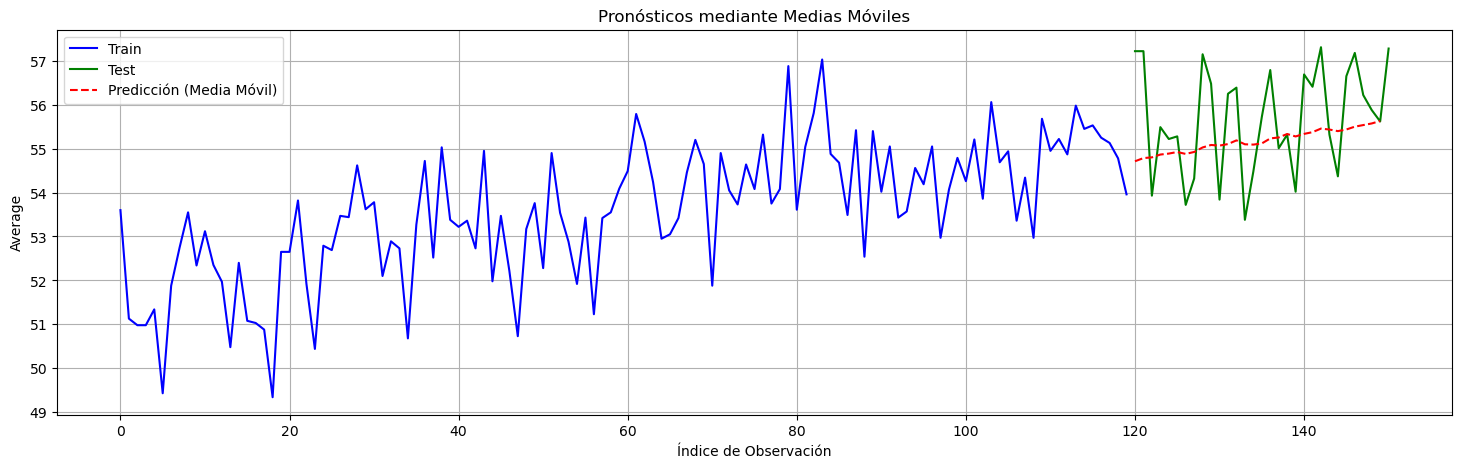

In [111]:
# Crear ejes X numéricos basados en el número de fila
x_train = np.arange(len(train))
x_test = np.arange(len(train), len(train) + len(test))

plt.figure(figsize=(18, 5))
plt.grid(True)

plt.plot(x_train, train['Average'].values, label="Train", color="blue")
plt.plot(x_test, test['Average'].values, label="Test", color="green")

y_pred_vals = y_pred_m.iloc[:, 0].values[-len(test):]
plt.plot(x_test[:len(y_pred_vals)], y_pred_vals, label="Predicción (Media Móvil)", color="red", linestyle="--")

plt.legend(loc="best")
plt.title("Pronósticos mediante Medias Móviles")
plt.xlabel("Índice de Observación")
plt.ylabel("Average")
plt.show()